In [1]:
import dpluspy
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pickle


matplotlib.rcParams["text.usetex"] = True
matplotlib.rcParams["text.latex.preamble"] = \
    r"\usepackage{amsmath}\usepackage{amssymb}"
matplotlib.rcParams["font.family"] = "serif"
matplotlib.rcParams["font.serif"] = "Computer Modern"
matplotlib.rcParams["savefig.bbox"] = "tight"
matplotlib.rcParams["axes.linewidth"] = 0.75
matplotlib.rcParams["font.size"] = 9
matplotlib.rcParams['xtick.labelsize'] = 7
matplotlib.rcParams['ytick.labelsize'] = 7
matplotlib.rcParams['ytick.major.size'] = 2
lw = 1

In [2]:
# file names

def load_pkl(fname):
    with open(fname, "rb") as fin: 
        ret = pickle.load(fin)
    return ret

bherer_data_file = "../data/statistics/main/stats_Bherer_weighted.pkl"
zhou_data_file = "../data/statistics/main/stats_ZhouJHS_weighted.pkl"

bherer_data = dpluspy.inference.load_stats(bherer_data_file, return_dict=True)
zhou_data = dpluspy.inference.load_stats(zhou_data_file, return_dict=True)
bherer_data = dpluspy.bootstrapping.subset_stats(
    bherer_data, to_pops=bherer_data["pop_ids"][:8], return_dict=True)
zhou_data = dpluspy.bootstrapping.subset_stats(
    zhou_data, to_pops=zhou_data["pop_ids"][:8], return_dict=True)

_model_cache = {}

def get_model(graph_file, data, u=1.3e-8):

    if graph_file in _model_cache:
        _model = _model_cache[graph_file]
    else:
        _model = dpluspy.inference.compute_bin_stats(
            graph_file, sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
        _model_cache[graph_file] = _model
    model = {
        "means": _model, "bins": data["bins"], "pop_ids": data["pop_ids"]}
    return model

In [3]:
def plot_stats_on_axs(
    stats, 
    axs, 
    color="tab:blue",
    linestyle="-", 
    labels=None, 
    fill=False,
    ylabel="$D^+$",
    plot_sqrhet=False,
    scale=1,
    kwargs={}
):
    shape = axs.shape
    axs = axs.flatten()
    ax_tracker = np.zeros(len(axs), np.int64)
    means = np.array(stats["means"])[:-1]
    if plot_sqrhet:
        hets = np.array(stats["means"])[-1] 
    if fill:
        varcovs = np.array(stats["varcovs"])[:-1]
    bins = stats["bins"]
    xx = 10 ** ((np.log10(bins[1:]) + np.log10(bins[:-1])) / 2)
    pop_ids = stats["pop_ids"]
    statistics = dpluspy.utils._DP_names(list(range(len(pop_ids))))

    mapping = {}
    tally = 0 
    for ii in range(len(pop_ids)):
        for jj in range(ii, len(pop_ids)):
            mapping[(ii, jj)] = tally
            tally += 1

    for (idx0, idx1), ax_idx in mapping.items():
        ax = axs[ax_idx]
        if labels is not None:
            if idx0 == idx1:
                label = labels[idx0]
            else:
                label = f"{labels[idx0]},{labels[idx1]}"
        else:
            label = None
        identifier = f"D+_{idx0}_{idx1}"
        idx = statistics.index(identifier)
        yy = means[:, idx] * scale
        # pick the color based on how many curves have been plotted so far

        if fill:
            err = varcovs[:, idx, idx] ** 0.5 * 1.96 * scale
            ax.fill_between(xx, yy - err, yy + err, alpha=0.3, color=color,
                            edgecolor="none")
        if linestyle is not None:
            ax.plot(xx, yy, linestyle, color=color, label=label, lw=lw, **kwargs)

        if plot_sqrhet:
            H2 = hets[idx] ** 2
            ax.scatter([0.02], [H2], marker="x", color=color, 
                       linewidth=lw)

        ax_tracker[ax_idx] += 1
    for ax in axs: 
        ax.set_xscale("log")
        ax.legend(framealpha=0, fontsize="x-small")
    # label axes of subplots at the left and bottom edges
    for ax in axs[-shape[1]:]:
        ax.set_xlabel("$r$")
    for ii in range(len(axs)):
        if ii % shape[1] == 0:
            axs[ii].set_ylabel(ylabel)
    return


def compute_residuals(data, model):
    varcovs = data["varcovs"]
    stds = [v[np.diag_indices(len(varcovs[0]))] ** 0.5 for v in varcovs]
    residuals = np.array(model) - np.array(data["means"])
    scaled_residuals = residuals / stds
    return scaled_residuals

KeyboardInterrupt: 

/home/nick/venvs/dpluspy/lib/python3.11/site-packages/matplotlib/dviread.py:1038: ResourceWarning: unclosed file <_io.BufferedWriter name=67>
  self._proc = self._new_proc()
/home/nick/venvs/dpluspy/lib/python3.11/site-packages/matplotlib/dviread.py:1038: ResourceWarning: unclosed file <_io.BufferedReader name=68>
  self._proc = self._new_proc()


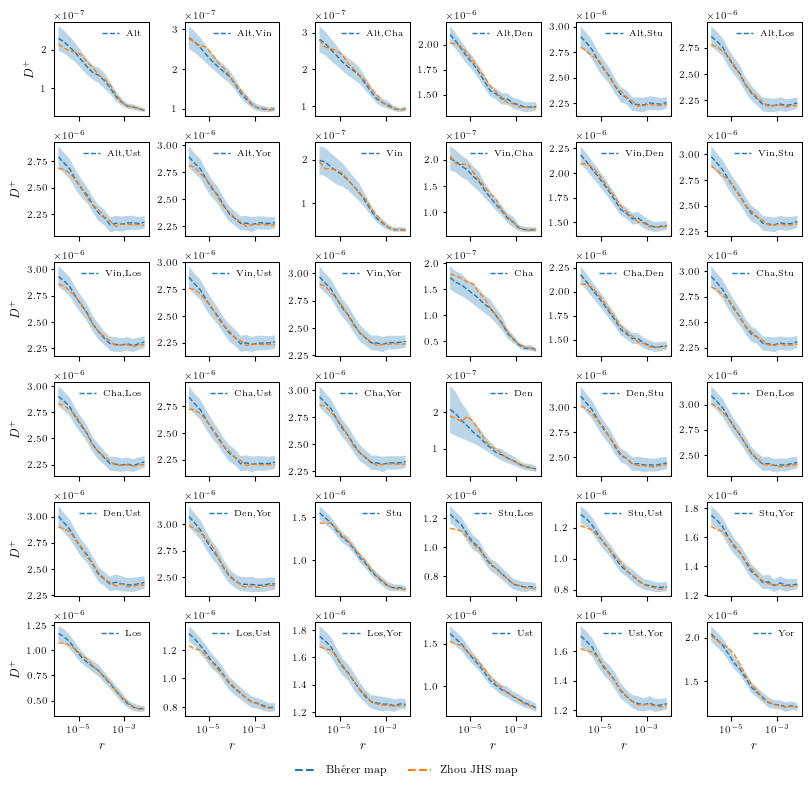

In [4]:
def plot_recombination_map_comp2(axs):
    labels = [x[:3] for x in bherer_data["pop_ids"]]
    plot_stats_on_axs(
        bherer_data, 
        axs, 
        color="tab:blue",
        linestyle="--",
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(
        zhou_data, 
        axs,
        color="tab:orange", 
        linestyle="--", 
        labels=None, 
        fill=False
    )
    return

fig, axs = plt.subplots(6, 6, figsize=(8, 7.5), layout="constrained", sharex=1)
plot_recombination_map_comp2(axs)
labels = [
    matplotlib.lines.Line2D(
        [], [], color="tab:blue", label="Bhérer map", linestyle="--"),
    matplotlib.lines.Line2D(
        [], [], color="tab:orange", label="Zhou JHS map", linestyle="--"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=2,
           bbox_to_anchor=(0.5, -0.04))
plt.savefig("figures/figS_main_rec_map_comp.pdf")

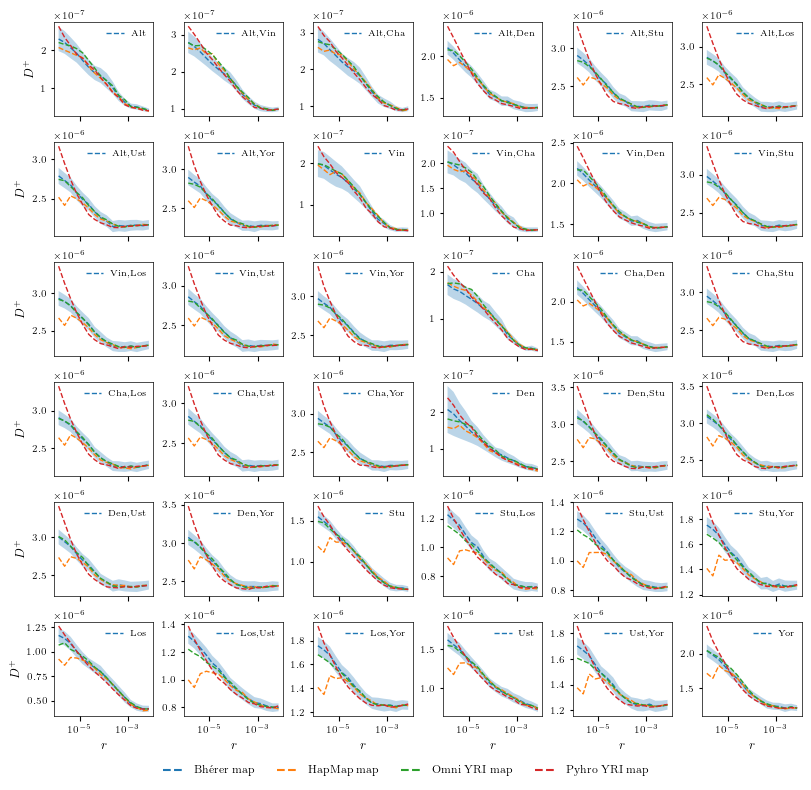

In [ ]:
def plot_recombination_map_comp4(axs):
    hapmap_data_file = "../analyses/recombination_maps/results/stats/stats_hapmap.pkl"
    omniYRI_data_file = "../analyses/recombination_maps/results/stats/stats_omniYRI.pkl"
    pyrhoYRI_data_file = "../analyses/recombination_maps/results/stats/stats_pyrhoYRI.pkl"

    hapmap_data = dpluspy.inference.load_stats(
        hapmap_data_file, return_dict=True, to_pops=bherer_data["pop_ids"])
    omni_data = dpluspy.inference.load_stats(
        omniYRI_data_file, return_dict=True, to_pops=bherer_data["pop_ids"])
    pyrho_data = dpluspy.inference.load_stats(
        pyrhoYRI_data_file, return_dict=True, to_pops=bherer_data["pop_ids"])
    
    labels = [x[:3] for x in bherer_data["pop_ids"]]
    plot_stats_on_axs(
        bherer_data, 
        axs, 
        color="tab:blue", 
        linestyle="--",
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(
        hapmap_data, 
        axs,
        color="tab:orange",
        linestyle="--", 
        labels=None
    )
    plot_stats_on_axs(
        omni_data, 
        axs,
        color="tab:green",
        linestyle="--", 
        labels=None
    )    
    plot_stats_on_axs(
        pyrho_data, 
        axs,
        color="tab:red",
        linestyle="--", 
        labels=None
    )
    return

fig, axs = plt.subplots(6, 6, figsize=(8, 7.5), layout="constrained", sharex=1)
plot_recombination_map_comp4(axs)
labels = [
    matplotlib.lines.Line2D(
        [], [], color="tab:blue", label="Bhérer map", linestyle="--"),
    matplotlib.lines.Line2D(
        [], [], color="tab:orange", label="HapMap map", linestyle="--"),
    matplotlib.lines.Line2D(
        [], [], color="tab:green", label="Omni YRI map", linestyle="--"),
    matplotlib.lines.Line2D(
        [], [], color="tab:red", label="Pyhro YRI map", linestyle="--"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=4,
           bbox_to_anchor=(0.5, -0.04))
plt.savefig("figures/figS_four_rec_map_comp.pdf")

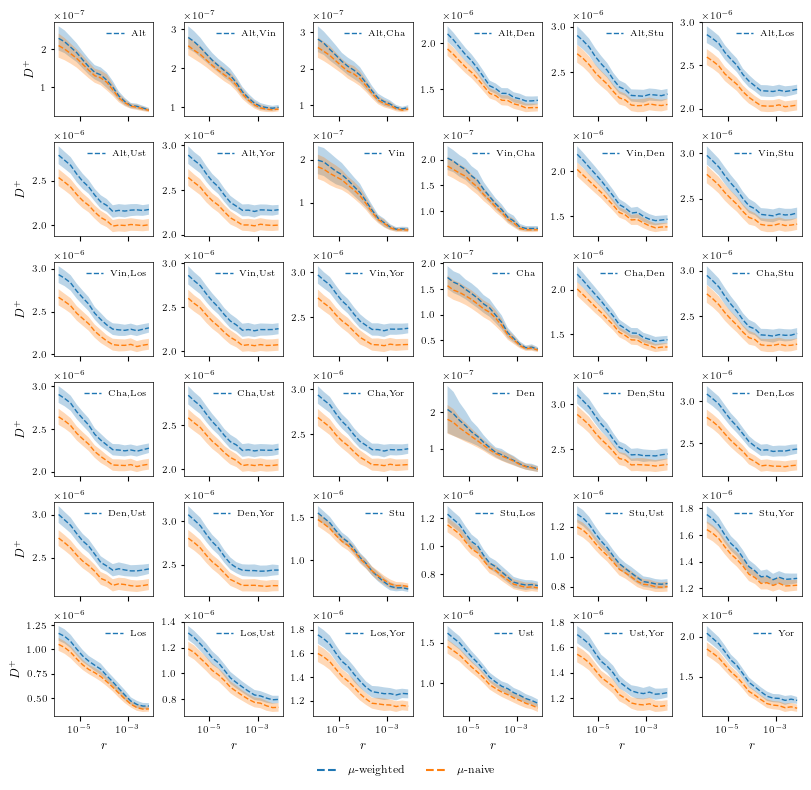

In [ ]:
def plot_weighting_comp(axs):
    data_file = "../data/statistics/main/stats_Bherer_naive.pkl"
    naive_data = dpluspy.inference.load_stats(
        data_file, return_dict=True, to_pops=bherer_data["pop_ids"])
    labels = [x[:3] for x in bherer_data["pop_ids"]]
    plot_stats_on_axs(
        bherer_data, 
        axs, 
        color="tab:blue", 
        linestyle="--",
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(
        naive_data, 
        axs,
        color="tab:orange",
        linestyle="--", 
        labels=None,
        fill=True
    )
    return

fig, axs = plt.subplots(6, 6, figsize=(8, 7.5), layout="constrained", sharex=1)
plot_weighting_comp(axs)
labels = [
    matplotlib.lines.Line2D(
        [], [], color="tab:blue", linestyle="--", label=r"$\mu$-weighted"),
    matplotlib.lines.Line2D(
        [], [], color="tab:orange", linestyle="--", label=r"$\mu$-naive"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=2,
           bbox_to_anchor=(0.5, -0.04))
plt.savefig("figures/figS_empirical_weighting_comp.pdf")

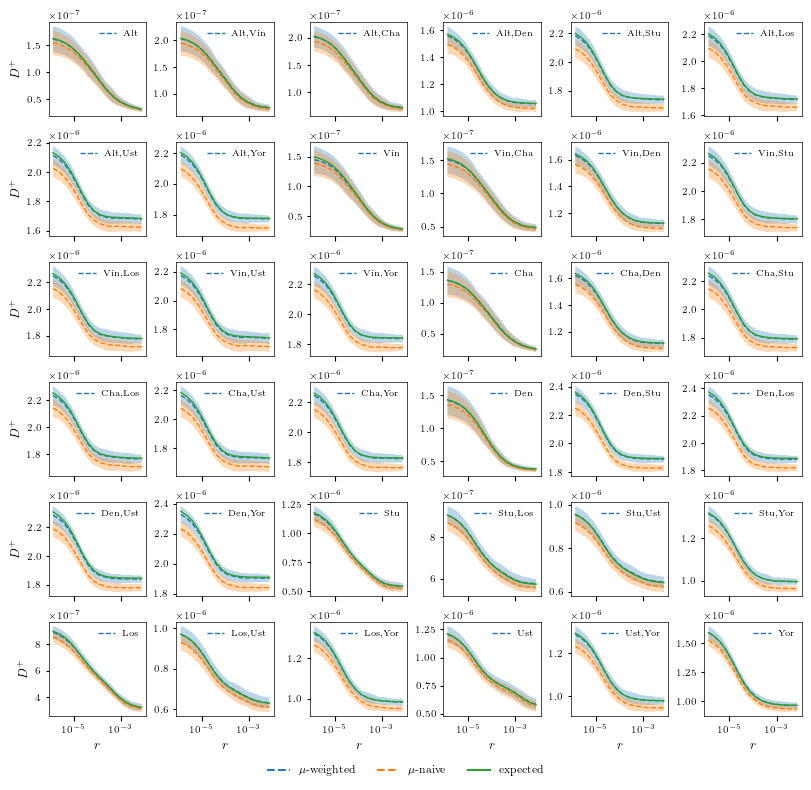

In [ ]:
def plot_sim_weighting_comp(axs):
    naive_file = "../simulations/weighting/naive_sims_50_reps_mean.pkl"
    weighted_file = "../simulations/weighting/weighted_sims_50_reps_mean.pkl"
    naive_data = dpluspy.inference.load_stats(
        naive_file, return_dict=True, to_pops=bherer_data["pop_ids"])
    weighted_data = dpluspy.inference.load_stats(
        weighted_file, return_dict=True, to_pops=bherer_data["pop_ids"])
    
    graph_file = "../simulations/weighting/simulation/full_model.yaml" 
    model = get_model(graph_file, naive_data, u=1.1525e-8)
    labels = [x[:3] for x in bherer_data["pop_ids"]]
    plot_stats_on_axs(
        weighted_data, 
        axs, 
        color="tab:blue", 
        linestyle="--",
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(
        naive_data, 
        axs,
        color="tab:orange",
        linestyle="--", 
        labels=None,
        fill=True
    )
    plot_stats_on_axs(
        model, 
        axs,
        color="tab:green", 
        labels=None,
    )
    return

fig, axs = plt.subplots(6, 6, figsize=(8, 7.5), layout="constrained", sharex=1)
plot_sim_weighting_comp(axs)
labels = [
    matplotlib.lines.Line2D(
        [], [], color="tab:blue", linestyle="--", label=r"$\mu$-weighted"),
    matplotlib.lines.Line2D(
        [], [], color="tab:orange", linestyle="--", label=r"$\mu$-naive"),
    matplotlib.lines.Line2D(
        [], [], color="tab:green", linestyle="-", label="expected"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=3,
           bbox_to_anchor=(0.5, -0.04))
plt.savefig("figures/figS_simulated_weighting_comp.pdf")

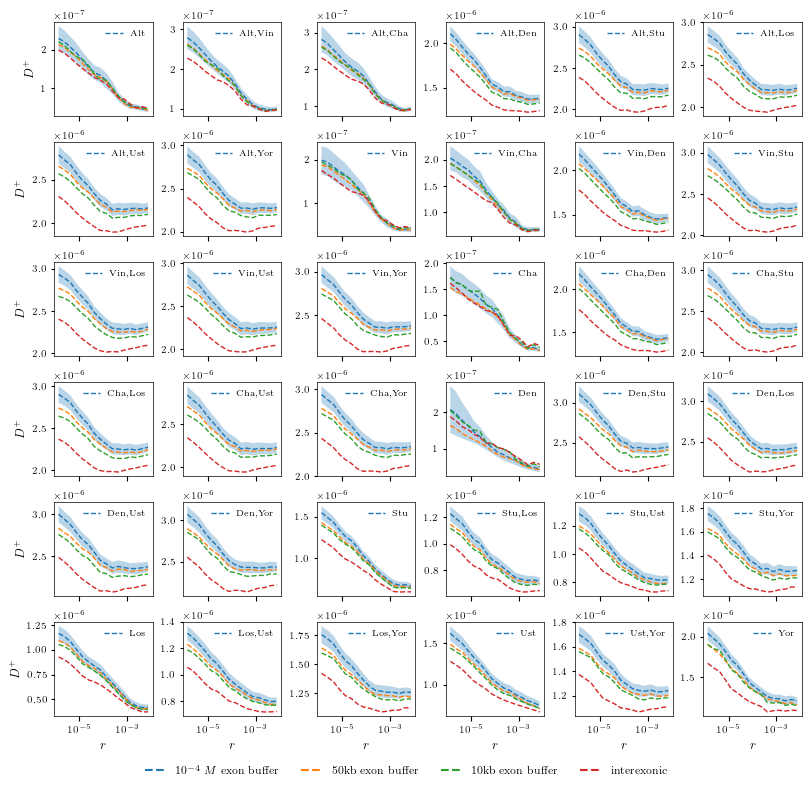

In [ ]:
def plot_exon_masking_comp(axs):
    intergenic_file = "../analyses/exon_buffers/results/stats/stats_intergenic.pkl"
    buffer10_file = "../analyses/exon_buffers/results/stats/stats_10kb_exon_buffer.pkl"
    buffer50_file = "../analyses/exon_buffers/results/stats/stats_50kb_exon_buffer.pkl"

    intergenic_data = dpluspy.inference.load_stats(
        intergenic_file, return_dict=True, to_pops=bherer_data["pop_ids"])
    buffer10_data = dpluspy.inference.load_stats(
        buffer10_file, return_dict=True, to_pops=bherer_data["pop_ids"])
    buffer50_data = dpluspy.inference.load_stats(
        buffer50_file, return_dict=True, to_pops=bherer_data["pop_ids"])
    
    labels = [x[:3] for x in bherer_data["pop_ids"]]
    plot_stats_on_axs(
        bherer_data, 
        axs, 
        color="tab:blue", 
        linestyle="--",
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(
        buffer50_data, 
        axs,
        color="tab:orange",
        linestyle="--", 
        labels=None
    )
    plot_stats_on_axs(
        buffer10_data, 
        axs,
        color="tab:green",
        linestyle="--", 
        labels=None
    )
    plot_stats_on_axs(
        intergenic_data, 
        axs,
        color="tab:red",
        linestyle="--", 
        labels=None
    )
    return


fig, axs = plt.subplots(6, 6, figsize=(8, 7.5), layout="constrained", sharex=1)
plot_exon_masking_comp(axs)
labels = [
    matplotlib.lines.Line2D(
        [], [], color="tab:blue", linestyle="--", label="$10^{-4}$ $M$ exon buffer"),
    matplotlib.lines.Line2D(
        [], [], color="tab:orange", linestyle="--", label="$50$kb exon buffer"),
    matplotlib.lines.Line2D(
        [], [], color="tab:green", linestyle="--", label="$10$kb exon buffer"),
    matplotlib.lines.Line2D(
        [], [], color="tab:red", label="interexonic", linestyle="--"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=4,
           bbox_to_anchor=(0.5, -0.04))
plt.savefig("figures/figS_mask_stringency_comp.pdf")

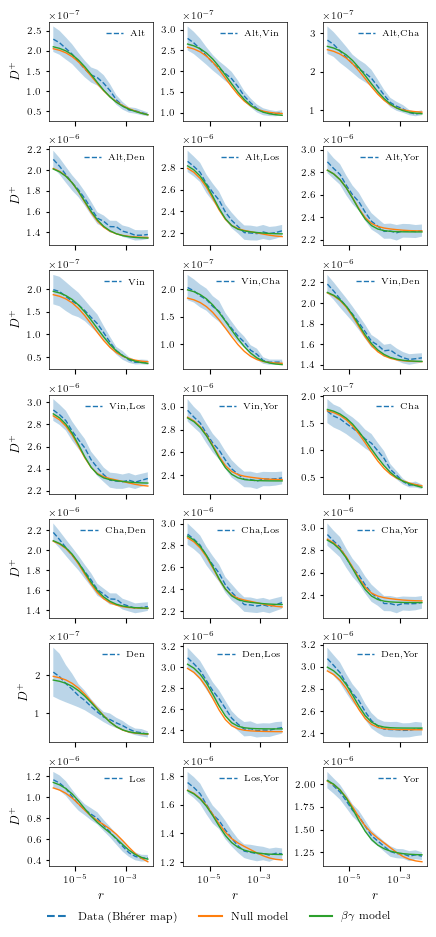

In [ ]:
def plot_hn_model_fits(axs):
    null_graph = "../models/human_neanderthal/main/fitted_models/null_Bherer_fit_10.yaml"
    alt_graph = "../models/human_neanderthal/main/fitted_models/pulses_Bherer_fit_4.yaml"
    data = dpluspy.inference.load_stats(
        bherer_data_file, graph=null_graph, return_dict=True)
    
    null_model = get_model(null_graph, data)
    alt_model = get_model(alt_graph, data)

    labels = [x[:3] for x in data["pop_ids"]]
    plot_stats_on_axs(
        data, 
        axs, 
        color="tab:blue", 
        linestyle="--", 
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(null_model, axs, color="tab:orange")
    plot_stats_on_axs(alt_model, axs, color="tab:green")
    return


fig, axs = plt.subplots(7, 3, figsize=(4.25, 9), layout="constrained", 
                        sharex=1)
plot_hn_model_fits(axs)
labels = [
    matplotlib.lines.Line2D(
        [], [], color="tab:blue", label="Data (Bhérer map)", linestyle="--"),
    matplotlib.lines.Line2D(
        [], [], color="tab:orange", label="Null model", linestyle="-"),
    matplotlib.lines.Line2D(
        [], [], color="tab:green", label=r"$\beta \gamma$ model", linestyle="-"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=3,
           bbox_to_anchor=(0.5, -0.03))
plt.savefig("figures/figS_human_neanderthal_model.pdf")


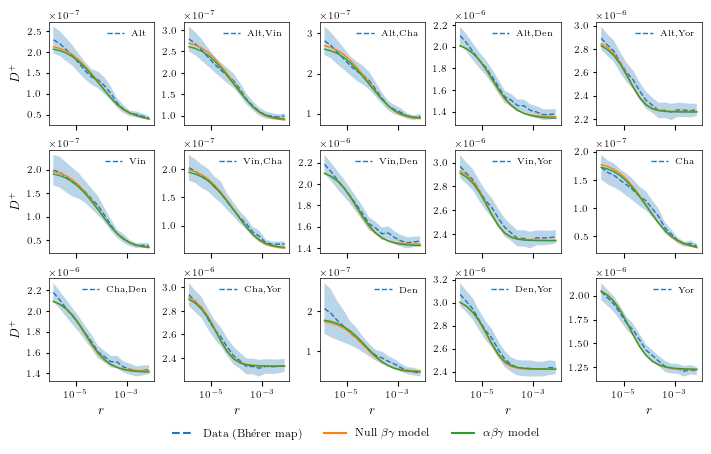

In [ ]:
def plot_modern_human_fits(axs):
    null_graph = "../models/ghost_introgression/main/fitted_models/null_Bherer_fit_16.yaml"
    alt_graph = "../models/ghost_introgression/main/fitted_models/fixed_2Ma_Bherer_fit_2.yaml"

    data = dpluspy.inference.load_stats(
        bherer_data_file, graph=null_graph, return_dict=True)
    
    null_model = get_model(null_graph, data)
    alt_model = get_model(alt_graph, data)

    labels = [x[:3] for x in data["pop_ids"]]
    plot_stats_on_axs(
        data, 
        axs, 
        color="tab:blue", 
        linestyle="--", 
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(null_model, axs, color="tab:orange")
    plot_stats_on_axs(alt_model, axs, color="tab:green")
    return


fig, axs = plt.subplots(3, 5, figsize=(7, 4.15), layout="constrained", 
                        sharex=1)
plot_modern_human_fits(axs)
labels = [
    matplotlib.lines.Line2D(
        [], [], color="tab:blue", label="Data (Bhérer map)", linestyle="--"),
    matplotlib.lines.Line2D(
        [], [], color="tab:orange", label=r"Null $\beta \gamma$ model"),
    matplotlib.lines.Line2D(
        [], [], color="tab:green", label=r"$\alpha \beta \gamma$ model"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=3,
           bbox_to_anchor=(0.5, -0.07))

plt.savefig("figures/figS_superarchaic_model.pdf")


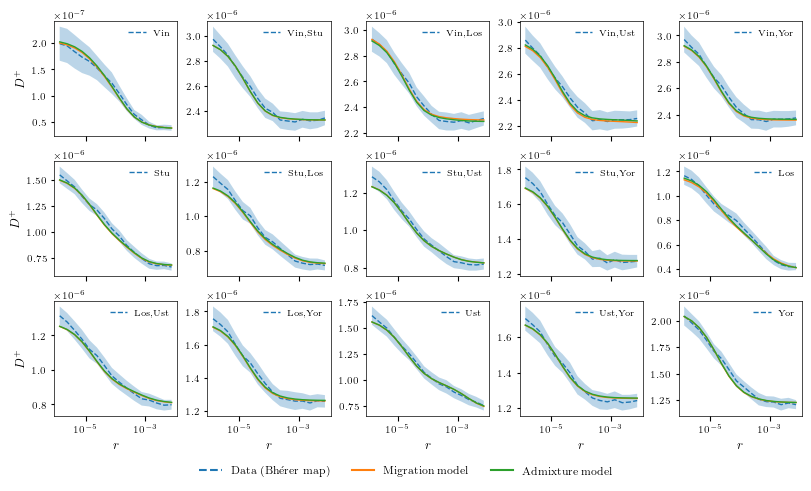

In [ ]:
def plot_modern_human_fits(axs):
    graph0 = "../models/modern_humans/main/best_fits/model_m_Bherer_fit_5.yaml"
    graph1 = "../models/modern_humans/main/best_fits/model_p_Bherer_fit_10.yaml"
    
    data = dpluspy.inference.load_stats(
        bherer_data_file, graph=graph0, return_dict=True)
    
    model0 = get_model(graph0, data)
    model1 = get_model(graph1, data)

    labels = [x[:3] for x in data["pop_ids"]]
    plot_stats_on_axs(
        data, 
        axs, 
        color="tab:blue", 
        linestyle="--", 
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(model0, axs, color="tab:orange")
    plot_stats_on_axs(model1, axs, color="tab:green")
    return


fig, axs = plt.subplots(3, 5, figsize=(8, 4.5), layout="constrained", 
                        sharex=1)
plot_modern_human_fits(axs)
labels = [
    matplotlib.lines.Line2D(
        [], [], color="tab:blue", label="Data (Bhérer map)", linestyle="--"),
    matplotlib.lines.Line2D([], [], color="tab:orange", label="Migration model"),
    matplotlib.lines.Line2D([], [], color="tab:green", label="Admixture model"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=3,
           bbox_to_anchor=(0.5, -0.07))
plt.savefig("figures/figS_human_models.pdf")

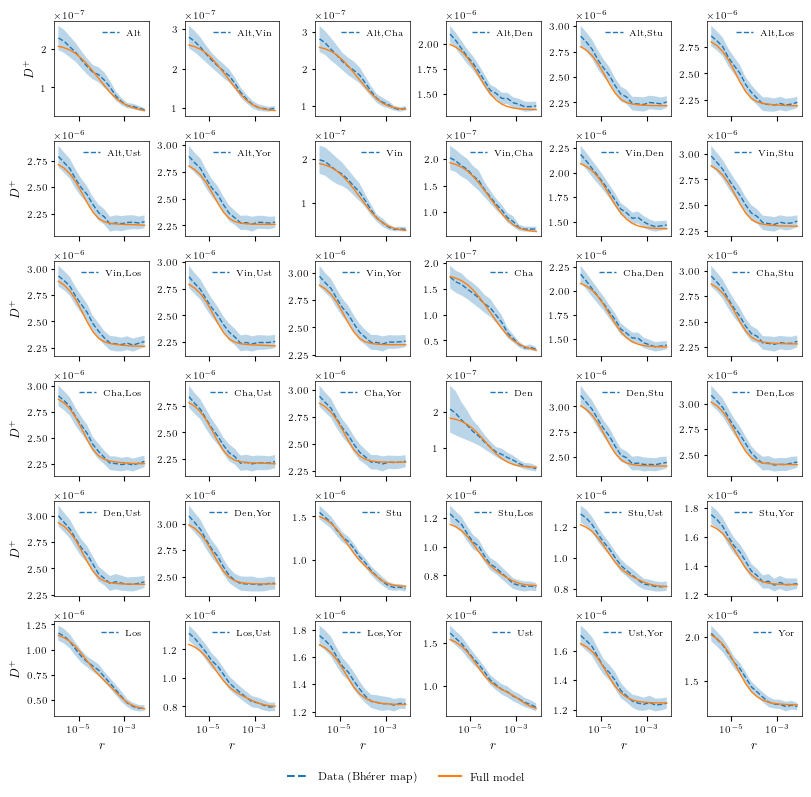

In [ ]:
def plot_full_model_bherer(axs):
    graph = "../models/full_model/round_6/fitted_models/full_model_round_6_Bherer_fit_13.yaml"
    model = get_model(graph, bherer_data)
    labels = [x[:3] for x in bherer_data["pop_ids"]]
    plot_stats_on_axs(
        bherer_data, 
        axs, 
        color="tab:blue", 
        linestyle="--", 
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(model, axs, color="tab:orange")
    return

fig, axs = plt.subplots(6, 6, figsize=(8, 7.5), layout="constrained", sharex=1)
plot_full_model_bherer(axs)
labels = [
    matplotlib.lines.Line2D(
        [], [], color="tab:blue", label="Data (Bhérer map)", linestyle="--"),
    matplotlib.lines.Line2D(
        [], [], color="tab:orange", label="Full model"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=2,
           bbox_to_anchor=(0.5, -0.05))
plt.savefig("figures/figS_full_model_bherer.pdf")

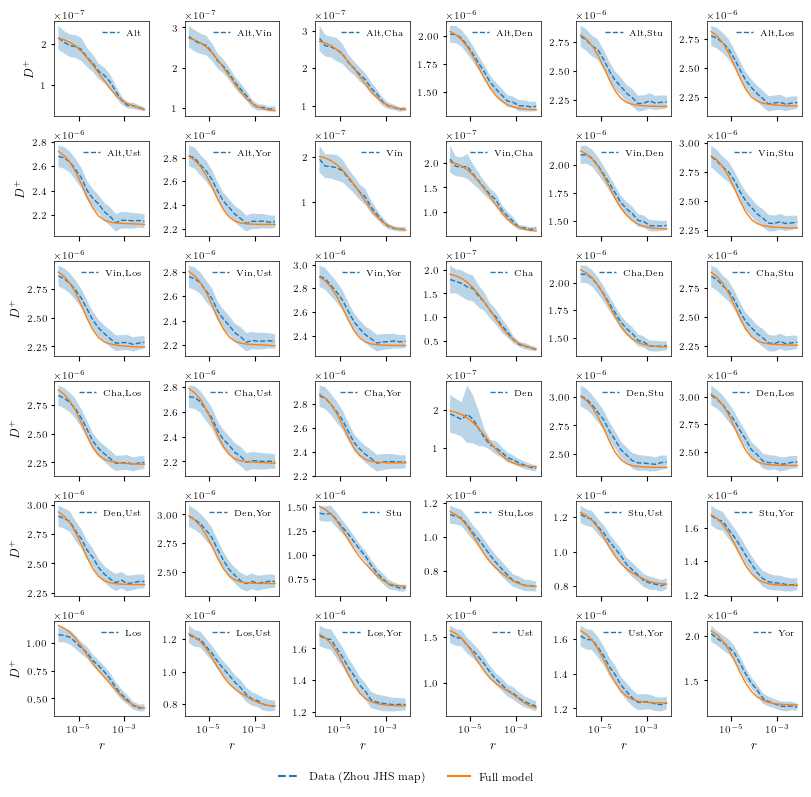

In [ ]:
def plot_full_model_zhou_jhs(axs):
    graph = "../models/full_model/round_6/fitted_models/full_model_round_6_ZhouJHS_fit_47.yaml"
    model = get_model(graph, zhou_data)
    labels = [x[:3] for x in zhou_data["pop_ids"]]
    plot_stats_on_axs(
        zhou_data, 
        axs, 
        color="tab:blue", 
        linestyle="--", 
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(model, axs, color="tab:orange")
    return

fig, axs = plt.subplots(6, 6, figsize=(8, 7.5), layout="constrained", sharex=1)
plot_full_model_zhou_jhs(axs)
labels = [
    matplotlib.lines.Line2D(
        [], [], color="tab:blue", label="Data (Zhou JHS map)", linestyle="--"),
    matplotlib.lines.Line2D(
        [], [], color="tab:orange", label="Full model"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=2,
           bbox_to_anchor=(0.5, -0.05))
plt.savefig("figures/figS_full_model_zhou.pdf")

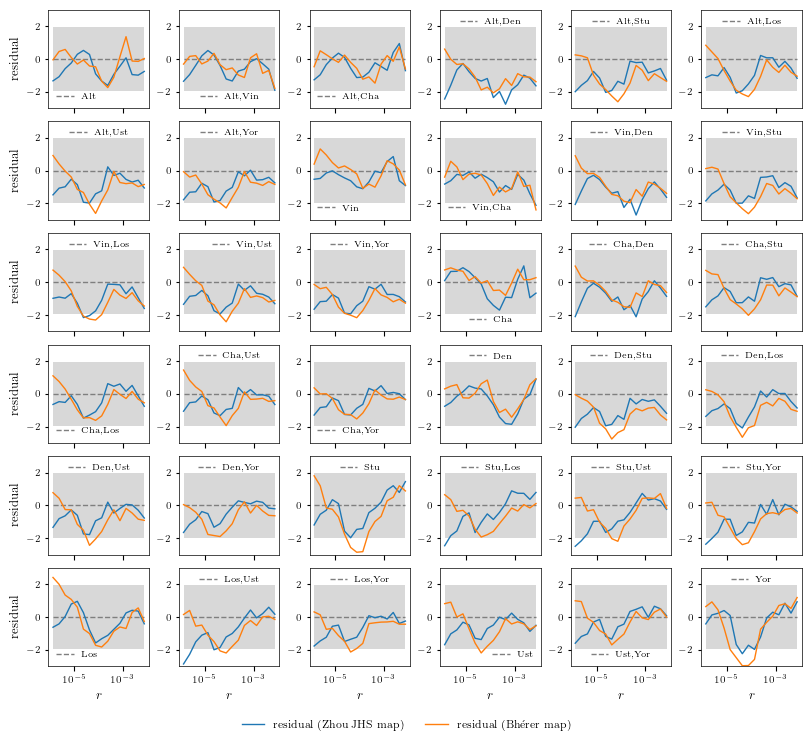

In [ ]:
def plot_full_model_residuals(axs):

    graph_bherer = "../models/full_model/round_6/fitted_models/full_model_round_6_Bherer_fit_13.yaml"
    bherer_model = get_model(graph_bherer, bherer_data)["means"]
    bherer_residuals = compute_residuals(bherer_data, bherer_model)
    plot_me_bherer = {"means": bherer_residuals, "bins": bherer_data["bins"],
                      "pop_ids": bherer_data["pop_ids"]}

    graph_zhou = "../models/full_model/round_6/fitted_models/full_model_round_6_ZhouJHS_fit_47.yaml"
    zhou_model = get_model(graph_zhou, zhou_data)["means"]
    zhou_residuals = compute_residuals(zhou_data, zhou_model)
    plot_me_zhou = {"means": zhou_residuals, "bins": zhou_data["bins"], 
                    "pop_ids": zhou_data["pop_ids"]}
    
    labels = [x[:3] for x in bherer_data["pop_ids"]]
    fake_data = {"bins": bherer_data["bins"], "pop_ids": bherer_data["pop_ids"]}
    fake_data["means"] = [np.zeros(m.shape) for m in bherer_data["means"]]
    fake_data["varcovs"] = [np.ones(v.shape) for v in bherer_data["varcovs"]]

    plot_stats_on_axs(
        fake_data, 
        axs, 
        color="tab:grey", 
        linestyle="--", 
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(plot_me_bherer, axs, color="tab:blue")
    plot_stats_on_axs(
        plot_me_zhou,
        axs,
        color="tab:orange",
        ylabel="residual"
    )
    return


fig, axs = plt.subplots(6, 6, figsize=(8, 7), layout="constrained", sharex=1)
plot_full_model_residuals(axs)
labels = [
    matplotlib.lines.Line2D([], [], lw=lw, color="tab:blue", 
                            label="residual (Zhou JHS map)"),
    matplotlib.lines.Line2D([], [], lw=lw, color="tab:orange", 
                            label="residual (Bhérer map)"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=2,
           bbox_to_anchor=(0.5, -0.05))
for ax in axs.flat:
    ax.set_ylim(-3, 3)
plt.savefig("figures/figS_full_model_residuals.pdf")


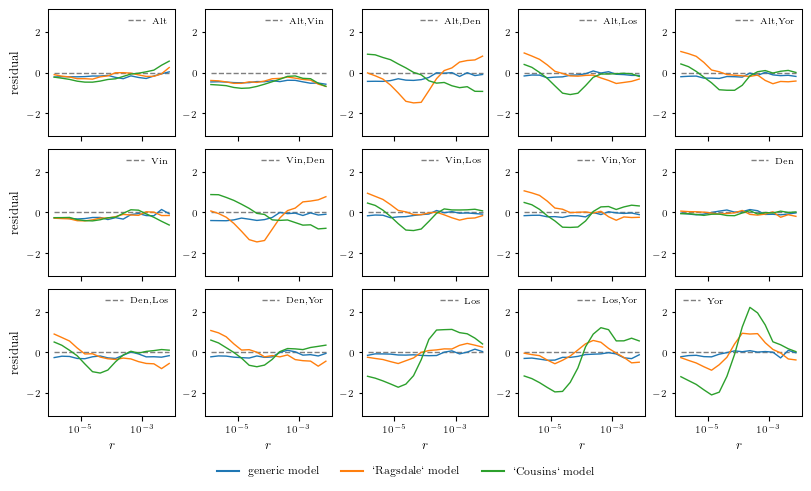

In [ ]:
## plot simulated residuals

with open("../simulations/structure_misspec/10_residuals.pkl", "rb") as fin:
    all_residuals = pickle.load(fin)


def plot_simulated_residuals(axs):
    example = all_residuals["ragsdale_0"]
    labels = [x[:3] for x in example["pop_ids"]]
    fake_data = {"bins": example["bins"], "pop_ids": example["pop_ids"]}
    fake_data["means"] = [np.zeros(m.shape) for m in example["means"]]
    fake_data["varcovs"] = [np.ones((len(v), len(v))) for v in example["means"]]

    plot_stats_on_axs(
        fake_data, 
        axs, 
        color="tab:grey", 
        linestyle="--", 
        labels=labels
    )

    models = ["generic", "ragsdale", "cousins"]
    colors = ["tab:blue", "tab:orange", "tab:green"]
    for model, color in zip(models, colors):
        arr = np.array([all_residuals[f"{model}_{i}"]["means"] for i in range(50)])
        tot_mean = np.mean(arr, axis=0)
        tot_varcovs = [np.cov(arr[:, i], rowvar=False) for i in range(len(tot_mean))]
        plot_me = {
            "means": tot_mean, 
            "varcovs": tot_varcovs,
            "bins": example["bins"], 
            "pop_ids": example["pop_ids"]}
        plot_stats_on_axs(plot_me, axs, color=color, fill=False, ylabel="residual")
    return


fig, axs = plt.subplots(3, 5, figsize=(8, 4.5), layout="constrained", sharex=1)
plot_simulated_residuals(axs)
labels = [
    matplotlib.lines.Line2D(
        [], [], color="tab:blue", label="generic model"),
    matplotlib.lines.Line2D(
        [], [], color="tab:orange", label="`Ragsdale` model"),
    matplotlib.lines.Line2D(
        [], [], color="tab:green", label="`Cousins` model"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=3,
           bbox_to_anchor=(0.5, -0.07))
for ax in axs.flat:
    ax.set_ylim(-3.1, 3.1)
plt.savefig("figures/figS_misspec_sim_residuals.pdf")


In [ ]:
model = "ragsdale"
arr = np.array([all_residuals[f"{model}_{i}"]["means"] for i in range(50)])
tot_mean = np.mean(arr, axis=0)
tot_varcovs = [np.cov(arr[:, i], rowvar=False) for i in range(len(tot_mean))]

In [ ]:
print(tot_mean.shape)
print(len(tot_varcovs))
print(tot_varcovs[0].shape)

(17, 15)
17
(15, 15)
